## CS421 Anomaly Detection 

#### Name: Justin Goh Kai Jun, Leong Zhe Cheng, Durga D/O Chandrasekaran
#### Group: G1T8

**Step 1: Imports and Setup**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy, rankdata, spearmanr, pearsonr
from scipy.spatial.distance import cdist

from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve, precision_recall_curve
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings, os
warnings.filterwarnings('ignore')

# random seed for clustering and autoencoder (deterministic)
np.random.seed(42)
torch.manual_seed(42)

# minimum AUC a model needs to enter the ensemble
ENSEMBLE_THRESHOLD = 0.65

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


**Step 2: Load Data**

In [2]:
data = np.load('../training_batch_with_labels.npz')
X_raw = data['X']
y_raw = data['y']

XX = pd.DataFrame(X_raw, columns=['user', 'item', 'rating'])
yy = pd.DataFrame(y_raw, columns=['user', 'label'])
label_map = dict(zip(yy['user'], yy['label']))

print(f'Total interactions : {XX.shape[0]:,}')
print(f'Anomalous users    : {(yy["label"] == 1).sum()}')
print(f'Normal users       : {(yy["label"] == 0).sum()}')
print(f'Unique users       : {XX["user"].nunique()}')
print(f'Anomaly ratio      : {(yy["label"]==1).sum() / len(yy):.2%}')
print(f'Unique items       : {XX["item"].nunique()}')

Total interactions : 177,346
Anomalous users    : 100
Normal users       : 1000
Unique users       : 1100
Anomaly ratio      : 9.09%
Unique items       : 993


In [5]:
# ITERATIVE: load newly released test labels
# Save test batch + released labels as: released_week1.npz -> keys:'X' (interactions), 'y'(labels, shape n_users x 2)
# Stack them all here automatically.
LABEL_DIR = '../released_labels'

extra_files = sorted([f for f in os.listdir(LABEL_DIR) if f.startswith('released_week')])
extra_interactions = []
extra_labels       = []

for fname in extra_files:
    d  = np.load(os.path.join(LABEL_DIR, fname))
    df = pd.DataFrame(d['X'], columns=['user', 'item', 'rating'])
    
    # Remap user IDs to avoid collision with training IDs
    # Offset by a large number unique to this file
    offset = (extra_files.index(fname) + 1) * 10_000
    df['user'] = df['user'] + offset
    lbl = pd.DataFrame(d['y'], columns=['user', 'label'])
    lbl['user'] = lbl['user'] + offset
    extra_interactions.append(df)
    extra_labels.append(lbl)
    n_anom = (lbl['label']==1).sum()
    print(f'  Loaded {fname}: {len(df):,} interactions, {n_anom} anomalies')

if extra_interactions:
    XX_extra = pd.concat(extra_interactions, ignore_index=True)
    yy_extra = pd.concat(extra_labels, ignore_index=True)
    XX = pd.concat([XX, XX_extra], ignore_index=True)
    yy = pd.concat([yy, yy_extra], ignore_index=True)
    label_map.update(dict(zip(yy_extra['user'], yy_extra['label'])))
    print(f'\nAfter stacking: {XX.shape[0]:,} interactions, {(yy["label"]==1).sum()} anomalies')

else:
    print('No released label files found. Running on original training data only.')
    print('(Drop released_weekN.npz files here to enable iterative retraining)')

No released label files found. Running on original training data only.
(Drop released_weekN.npz files here to enable iterative retraining)


In [6]:
print('Interactions (XX):'); display(XX.head())
print('Labels (yy):');       display(yy.head())

Interactions (XX):


,user,item,rating
0,304,0,3
1,304,1,3
2,304,14,3
3,304,17,4
4,304,19,4


Labels (yy):


,user,label
0,100,0
1,101,0
2,102,0
3,103,0
4,104,0


**Step 3: Feature Engineering**

**Helper function 1:** `compute_item_stats` calculates three things across all interactions: the mean rating per item, the number of ratings per item (popularity), and a percentile rank of each item's popularity from 0 to 1. These are needed for the attack-profile features.

In [7]:
def compute_item_stats(interactions_df):
    """Compute item-level stats needed for attack-profile features."""
    item_mean   = interactions_df.groupby('item')['rating'].mean()
    item_count  = interactions_df.groupby('item')['rating'].count()
    item_pop_rank = item_count.rank(pct=True)  # 0=least popular, 1=most popular
    return item_mean, item_count, item_pop_rank

**Helper function 2:** `engineer_all_features` then loops over every user and builds a 38-number vector describing their behaviour. These break into three groups:
- **Rating statistics**: `mean`, `std`, `variance`, `min`, `max`, `range`, `fraction of each star level (0-5)`, `entropy of the rating distribution`, `fractions of extreme/zero/five/mid ratings`, `bimodality score`, and `skewness`. These capture the overall shape of how a user rates.
    
- **Item behaviour**: `number of interactions`, `unique items rated`, `density`, `fraction of repeat-rated items`, `item ID gap statistics` (mean, std, min gap between sorted item IDs), `sequential run fraction`, `item-rating autocorrelation` (whether ratings systematically change with item ID order), and `burst score` (whether 80% of interactions are concentrated on very few items)
  
- **Attack-profile features**: `avg_attack_score` (how closely a user rates items near their mean -> an average attacker tries to blend in by mimicking item averages), `bandwagon_score` (Pearson correlation between a user's ratings and item popularity -> bandwagon attackers inflate popular items), `random_attack_score` (normalised entropy -> random attackers produce a uniform distribution across all star levels), `segment_score` (combines popular item concentration with extreme ratings), `love_hate_score` (the fraction of 0 and 5 star ratings combined), `rating_deviation_std` (how consistently a user deviates from item averages)<br><br>
After the loop, the cosine deviation is computed -> each user's star-fraction vector is compared to the centroid of normal users using cosine similarity, and the distance from that centroid becomes a feature.

In [8]:
def engineer_all_features(interactions_df, n_items=1000, normal_centroid=None, item_mean=None, item_count=None, item_pop_rank=None):
    """Build per-user feature matrix. Returns (feat_arr, user_ids, normal_centroid)."""

    if item_mean is None:
        item_mean, item_count, item_pop_rank = compute_item_stats(interactions_df)

    features  = []
    user_ids  = interactions_df['user'].unique()

    for uid in user_ids:
        u_df    = interactions_df[interactions_df['user'] == uid]
        ratings = u_df['rating'].values.astype(float)
        items   = u_df['item'].values

        # Basic rating stats
        mean_r     = ratings.mean()
        std_r      = ratings.std()   if len(ratings) > 1 else 0.0
        variance_r = ratings.var()   if len(ratings) > 1 else 0.0
        min_r, max_r = ratings.min(), ratings.max()
        range_r    = max_r - min_r

        star_fracs     = np.bincount(ratings.astype(int), minlength=6) / max(len(ratings), 1)
        rating_entropy = entropy(star_fracs + 1e-9)

        frac_extreme = np.mean((ratings == 0) | (ratings == 5))
        frac_zero    = np.mean(ratings == 0)
        frac_five    = np.mean(ratings == 5)
        frac_mid     = np.mean((ratings >= 2) & (ratings <= 3))
        frac_45      = np.mean(ratings >= 4)
        frac_01      = np.mean(ratings <= 1)
        bimodal      = frac_45 + frac_01

        rating_skew = ((ratings - mean_r)**3).mean() / (std_r**3 + 1e-9)

        # Interaction count features
        n_interactions = len(ratings)
        n_unique_items = len(np.unique(items))
        density        = n_interactions / n_items
        item_counts_u  = pd.Series(items).value_counts()
        n_repeat_items = (item_counts_u > 1).sum() / max(len(item_counts_u), 1)

        # Item gap features
        sorted_items = np.sort(items)
        item_gaps    = np.diff(sorted_items) if len(sorted_items) > 1 else np.array([0])
        mean_gap     = item_gaps.mean()
        std_gap      = item_gaps.std()  if len(item_gaps) > 1 else 0.0
        min_gap      = item_gaps.min()

        # Sequential run fraction
        sequential_run_frac = (item_gaps == 1).sum() / max(len(item_gaps), 1)

        # Item-rating autocorrelation
        if len(items) > 3:
            sort_idx      = np.argsort(items)
            sorted_r      = ratings[sort_idx]
            item_autocorr, _ = spearmanr(np.arange(len(sorted_r)), sorted_r)
            item_autocorr = abs(item_autocorr) if not np.isnan(item_autocorr) else 0.0
        else:
            item_autocorr = 0.0

        # Burst score
        if n_unique_items > 1:
            sorted_counts = np.sort(item_counts_u.values)[::-1]
            cumulative    = np.cumsum(sorted_counts) / sorted_counts.sum()
            items_for_80  = np.searchsorted(cumulative, 0.8) + 1
            burst_score   = 1.0 - (items_for_80 / n_unique_items)
        else:
            burst_score = 1.0

        # Cosine deviation
        cosine_dev = 0.0

        # ATTACK PROFILE FEATURES

        # 1. Average attack: rate items close to their mean (suspicious)
        rated_items_means = item_mean.reindex(items).fillna(item_mean.mean()).values
        avg_attack_score  = 1.0 - np.mean(np.abs(ratings - rated_items_means)) / 5.0

        # 2. Bandwagon: high correlation between rating and item popularity
        item_pops = item_pop_rank.reindex(items).fillna(0.5).values
        if len(items) > 3:
            corr, _ = pearsonr(item_pops, ratings)
            bandwagon_score = abs(corr) if not np.isnan(corr) else 0.0
        else:
            bandwagon_score = 0.0

        # 3. Random attack: very uniform/high entropy rating distribution
        # A perfectly random attacker has max entropy across all 6 star levels
        max_entropy     = entropy(np.ones(6) / 6)
        random_attack_score = rating_entropy / max_entropy  # 1.0 = perfectly random

        # 4. Segment attack: concentrate on a small popular subset
        popular_items   = set(item_pop_rank[item_pop_rank >= 0.8].index)
        unpopular_items = set(item_pop_rank[item_pop_rank <= 0.2].index)
        popular_item_frac   = np.mean([i in popular_items   for i in items])
        unpopular_item_frac = np.mean([i in unpopular_items for i in items])
        # Segment score: high if concentrated on popular items + gives extreme ratings
        segment_score = popular_item_frac * frac_extreme

        # 5. Love/hate: give only 0s or 5s (push/nuke attack)
        love_hate_score = frac_zero + frac_five

        # 6. Rating consistency vs item average
        rating_deviation_std = np.std(ratings - rated_items_means) if len(ratings) > 1 else 0.0

        features.append(np.array([
            mean_r, std_r, variance_r, min_r, max_r, range_r,
            *star_fracs,
            rating_entropy,
            frac_extreme, frac_zero, frac_five, frac_mid,
            frac_45, frac_01, bimodal,
            rating_skew,
            n_interactions, n_unique_items, density,
            mean_gap, std_gap, min_gap,
            sequential_run_frac,
            item_autocorr,
            burst_score,
            n_repeat_items,
            cosine_dev,
            avg_attack_score,
            bandwagon_score,
            random_attack_score,
            popular_item_frac,
            unpopular_item_frac,
            segment_score,
            love_hate_score,
            rating_deviation_std,
        ]))

    feat_arr  = np.array(features)
    star_cols = list(range(6, 12))

    if normal_centroid is None:
        normal_centroid = feat_arr[:, star_cols].mean(axis=0)

    star_vecs     = feat_arr[:, star_cols]
    norms         = np.linalg.norm(star_vecs, axis=1, keepdims=True) + 1e-9
    centroid_norm = np.linalg.norm(normal_centroid) + 1e-9
    cosine_sim    = (star_vecs / norms) @ (normal_centroid / centroid_norm)
    feat_arr[:, ALL_FEATURE_NAMES.index('cosine_dev')] = 1.0 - cosine_sim

    return feat_arr, user_ids, normal_centroid

In [10]:
ALL_FEATURE_NAMES = [
    'mean_r', 'std_r', 'variance_r', 'min_r', 'max_r', 'range_r',
    'star0', 'star1', 'star2', 'star3', 'star4', 'star5',
    'entropy',
    'frac_extreme', 'frac_zero', 'frac_five', 'frac_mid',
    'frac_45', 'frac_01', 'bimodal',
    'rating_skew',
    'n_inter', 'n_unique_items', 'density',
    'mean_gap', 'std_gap', 'min_gap',
    'sequential_run_frac',
    'item_autocorr',
    'burst_score',
    'n_repeat_items',
    'cosine_dev',
    
    # Attack profile features
    'avg_attack_score',
    'bandwagon_score',
    'random_attack_score',
    'popular_item_frac',
    'unpopular_item_frac',
    'segment_score',
    'love_hate_score',
    'rating_deviation_std',
]

ATTACK_FEATURES = {
    'avg_attack_score', 'bandwagon_score', 'random_attack_score',
    'popular_item_frac', 'unpopular_item_frac', 'segment_score',
    'love_hate_score', 'rating_deviation_std'
}

# First pass to get label alignment
ITEM_MEAN, ITEM_COUNT, ITEM_POP_RANK = compute_item_stats(XX)

feat_matrix_raw, feat_user_ids, _ = engineer_all_features(
    XX, item_mean=ITEM_MEAN, item_count=ITEM_COUNT, item_pop_rank=ITEM_POP_RANK
)
y_true = np.array([label_map[u] for u in feat_user_ids])

# Compute normal-only centroid 
normal_mask     = y_true == 0
NORMAL_CENTROID = feat_matrix_raw[normal_mask, 6:12].mean(axis=0)

# Second pass with correct centroid
feat_matrix_all, feat_user_ids, NORMAL_CENTROID = engineer_all_features(
    XX, normal_centroid=NORMAL_CENTROID,
    item_mean=ITEM_MEAN, item_count=ITEM_COUNT, item_pop_rank=ITEM_POP_RANK
)
y_true = np.array([label_map[u] for u in feat_user_ids])

print(f'Feature matrix : {feat_matrix_all.shape}')
print(f'Total anomalies: {y_true.sum()} / {len(y_true)}')

Feature matrix : (1100, 40)
Total anomalies: 100 / 1100


**Step 4: Feature Selection**

Each feature is evaluated individually by computing its AUC against the true labels. Features below 0.55 AUC (worse than random after flipping) are dropped as they add noise without signal.

The notebook also identifies the top 3 features, and splits the remaining selected features into two views -> a rating view (features about how users rate) and an item view (features about which items users interact with). These views are used to train separate GMM models, giving the ensemble more diversity.

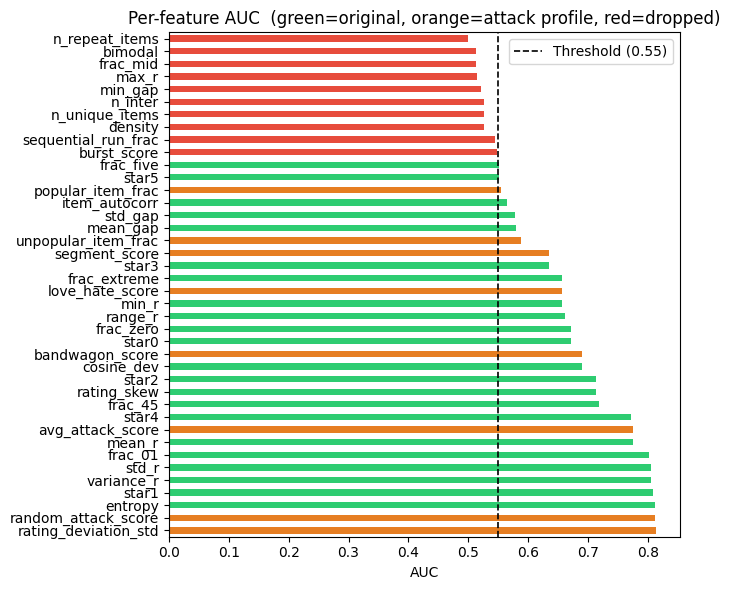

Selected (30): ['mean_r', 'std_r', 'variance_r', 'min_r', 'range_r', 'star0', 'star1', 'star2', 'star3', 'star4', 'star5', 'entropy', 'frac_extreme', 'frac_zero', 'frac_five', 'frac_45', 'frac_01', 'rating_skew', 'mean_gap', 'std_gap', 'item_autocorr', 'cosine_dev', 'avg_attack_score', 'bandwagon_score', 'random_attack_score', 'popular_item_frac', 'unpopular_item_frac', 'segment_score', 'love_hate_score', 'rating_deviation_std']
Dropped  (10):  ['max_r', 'frac_mid', 'bimodal', 'n_inter', 'n_unique_items', 'density', 'min_gap', 'sequential_run_frac', 'burst_score', 'n_repeat_items']
Top-3    : ['rating_deviation_std', 'entropy', 'random_attack_score']
Rating view features (23): ['mean_r', 'std_r', 'variance_r', 'min_r', 'range_r', 'star0', 'star1', 'star2', 'star3', 'star4', 'star5', 'entropy', 'frac_extreme', 'frac_zero', 'frac_five', 'frac_45', 'frac_01', 'rating_skew', 'cosine_dev', 'avg_attack_score', 'random_attack_score', 'love_hate_score', 'rating_deviation_std']
Item view featur

In [11]:
feat_df = pd.DataFrame(feat_matrix_all, columns=ALL_FEATURE_NAMES)

feature_aucs = {}
for col in ALL_FEATURE_NAMES:
    auc = roc_auc_score(y_true, feat_df[col].values)
    feature_aucs[col] = auc if auc >= 0.5 else 1 - auc

auc_series = pd.Series(feature_aucs).sort_values(ascending=False)

KEEP_THRESHOLD = 0.55
colors = []
for f in auc_series.index:
    if auc_series[f] < KEEP_THRESHOLD:
        colors.append('#e74c3c')
    elif f in ATTACK_FEATURES:
        colors.append('#e67e22')
    else:
        colors.append('#2ecc71')

plt.figure(figsize=(7, 6))
auc_series.plot(kind='barh', color=colors)
plt.axvline(KEEP_THRESHOLD, color='black', linestyle='--', linewidth=1.2,
            label=f'Threshold ({KEEP_THRESHOLD})')
plt.xlabel('AUC')
plt.title('Per-feature AUC  (green=original, orange=attack profile, red=dropped)')
plt.legend()
plt.tight_layout()
plt.show()

SELECTED_FEATURES = [f for f in ALL_FEATURE_NAMES if feature_aucs[f] >= KEEP_THRESHOLD]
DROPPED_FEATURES  = [f for f in ALL_FEATURE_NAMES if feature_aucs[f] < KEEP_THRESHOLD]
TOP3              = [f for f, _ in sorted(feature_aucs.items(), key=lambda x: x[1], reverse=True)[:3]]
selected_idx = [ALL_FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]
top3_idx     = [ALL_FEATURE_NAMES.index(f) for f in TOP3]

print(f'Selected ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}')
print(f'Dropped  ({len(DROPPED_FEATURES)}):  {DROPPED_FEATURES}')
print(f'Top-3    : {TOP3}')

# Feature views for diverse ensemble 
RATING_FEATURES = [f for f in SELECTED_FEATURES
                   if f in {'mean_r','std_r','variance_r','min_r','max_r','range_r',
                             'star0','star1','star2','star3','star4','star5',
                             'entropy','frac_extreme','frac_zero','frac_five',
                             'frac_mid','frac_45','frac_01','bimodal','rating_skew',
                             'cosine_dev','avg_attack_score','random_attack_score',
                             'love_hate_score','rating_deviation_std'}]
ITEM_FEATURES   = [f for f in SELECTED_FEATURES
                   if f in {'n_inter','n_unique_items','density','mean_gap','std_gap',
                             'min_gap','sequential_run_frac','item_autocorr','burst_score',
                             'n_repeat_items','bandwagon_score','popular_item_frac',
                             'unpopular_item_frac','segment_score'}]

rating_idx = [ALL_FEATURE_NAMES.index(f) for f in RATING_FEATURES]
item_idx   = [ALL_FEATURE_NAMES.index(f) for f in ITEM_FEATURES]

print(f'Rating view features ({len(RATING_FEATURES)}): {RATING_FEATURES}')
print(f'Item view features   ({len(ITEM_FEATURES)}):   {ITEM_FEATURES}')

**Step 5: Scaling normal only**

Four separate StandardScaler objects are fit (full feature set, top-3, the rating view, and the item view). Critically, all four are fit only on the rows where y_true == 0 (normal users). The scaler learns what "normal" looks like, and anything that deviates from that after scaling is naturally more visible.

In [12]:
feat_matrix   = feat_matrix_all[:, selected_idx]
feat_top3     = feat_matrix_all[:, top3_idx]
feat_rating   = feat_matrix_all[:, rating_idx]
feat_item     = feat_matrix_all[:, item_idx]

normal_mask   = y_true == 0

scaler = StandardScaler()
scaler.fit(feat_matrix[normal_mask])
feat_scaled = scaler.transform(feat_matrix)
X_train_normal = feat_scaled[normal_mask]

top3_scaler = StandardScaler()
top3_scaler.fit(feat_top3[normal_mask])
feat_top3_scaled = top3_scaler.transform(feat_top3)

rating_scaler = StandardScaler()
rating_scaler.fit(feat_rating[normal_mask])
feat_rating_scaled = rating_scaler.transform(feat_rating)

item_scaler = StandardScaler()
item_scaler.fit(feat_item[normal_mask])
feat_item_scaled = item_scaler.transform(feat_item)

X_normal_rating = feat_rating_scaled[normal_mask]
X_normal_item   = feat_item_scaled[normal_mask]

print(f'Full feature matrix  : {feat_scaled.shape}')
print(f'Rating view          : {feat_rating_scaled.shape}')
print(f'Item view            : {feat_item_scaled.shape}')
print(f'Normal training rows : {X_train_normal.shape[0]}')

Full feature matrix  : (1100, 30)
Rating view          : (1100, 23)
Item view            : (1100, 7)
Normal training rows : 1000


**Others: Utilities (Helper functions)**

**Helper function 1:** `evaluate` computes AUC, F1, precision and recall for any model. Tt finds the optimal threshold by maximising F1 on the precision-recall curve. 

In [13]:
def evaluate(y_true_eval, scores, model_name):
    auc = roc_auc_score(y_true_eval, scores)
    precisions, recalls, thresholds = precision_recall_curve(y_true_eval, scores)
    f1s      = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1s)
    threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    y_pred   = (scores >= threshold).astype(int)
    f1   = f1_score(y_true_eval, y_pred, zero_division=0)
    prec = precision_score(y_true_eval, y_pred, zero_division=0)
    rec  = recall_score(y_true_eval, y_pred, zero_division=0)
    print(f'[{model_name}]  AUC={auc:.4f}  F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}')
    return {'model': model_name, 'AUC': auc, 'F1': f1, 'Precision': prec, 'Recall': rec}

**Helper function 2:** `normalize` maps any array to [0,1] by min-max scaling.<br>
**Helper function 3:** `rank_normalize` replaces values with their percentile rank<br>
**Helper function 4:** `power_stretch` is the score stretching function that rank-normalises first (so all models are on a uniform scale), then raises to the power 0.4, which pushes high scores toward 1.0 and low scores toward 0.0<br>
**Helper function 5:**: `hbos_score` implements HBOS from scratch. For each feature, it builds a histogram on training data and scores test users by how unlikely their value is in each histogram bin, summing across all features.

In [14]:
def normalize(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)

def rank_normalize(arr):
    return rankdata(arr) / len(arr)

def power_stretch(arr, power=0.4):
    """Rank-normalise then apply power transform to spread scores toward [0,1].
    power < 1 pulls low scores up (stretches the top end more).
    power > 1 pushes low scores down (sharpens separation).
    0.4 is a good default for anomaly detection with ~9% anomaly rate.
    """
    ranked = rank_normalize(arr)        # uniform [0,1] by rank
    return np.power(ranked, power)      # stretch

def hbos_score(X_train, X_test, n_bins=10):
    scores = np.zeros(len(X_test))
    for j in range(X_train.shape[1]):
        hist, bin_edges = np.histogram(X_train[:, j], bins=n_bins, density=True)
        hist = np.maximum(hist, 1e-10)
        for i, val in enumerate(X_test[:, j]):
            bin_idx = np.searchsorted(bin_edges[1:], val, side='right')
            bin_idx = min(bin_idx, n_bins - 1)
            scores[i] += -np.log(hist[bin_idx] + 1e-10)
    return scores

method_scores = {}   # {name: (normalised_scores, auc)}
oof_scores    = {}   # {name: raw oof scores} for stacking
results       = []

**Step 6: Unsupervised models**

**GMM Model:** Three GMM models are trained
- **1st:** on the full selected features
- **2nd:** one on the rating view
- **3rd:** one on the item view

For each, the number of components (2 to 6) is swept and the best is kept. All three are trained exclusively on X_train_normal (normal users only). The anomaly score is the negative log-likelihood (how unlikely a user's feature vector is under the normal distribution the GMM learned). A user who looks nothing like any of the normal clusters gets a high score.

In [15]:
# GMM on full features
best_gmm_n, best_gmm_auc = 1, 0
for n in [2, 3, 4, 5, 6]:
    g = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    g.fit(X_train_normal)
    sc  = -g.score_samples(feat_scaled)
    auc = roc_auc_score(y_true, sc)
    if auc > best_gmm_auc:
        best_gmm_n, best_gmm_auc = n, auc

gmm = GaussianMixture(n_components=best_gmm_n, covariance_type='full', random_state=42)
gmm.fit(X_train_normal)
gmm_scores = -gmm.score_samples(feat_scaled)
auc_gmm    = roc_auc_score(y_true, gmm_scores)
method_scores['GMM'] = (normalize(gmm_scores), auc_gmm)
results.append(evaluate(y_true, gmm_scores, f'GMM n={best_gmm_n}'))

# GMM on rating view
best_rn, best_rauc, best_rcov = 2, 0, 'full'
for n in [2, 3, 4, 5]:
    for cov in ['full', 'diag', 'tied']:
        g = GaussianMixture(n_components=n, covariance_type=cov, random_state=42)
        g.fit(X_normal_rating)
        sc  = -g.score_samples(feat_rating_scaled)
        auc = roc_auc_score(y_true, sc)
        if auc > best_rauc:
            best_rn, best_rauc, best_rcov = n, auc, cov

gmm_rating = GaussianMixture(n_components=best_rn, covariance_type=best_rcov, random_state=42)
gmm_rating.fit(X_normal_rating)
gmm_rating_scores = -gmm_rating.score_samples(feat_rating_scaled)
auc_gmm_r = roc_auc_score(y_true, gmm_rating_scores)
method_scores['GMM (rating view)'] = (normalize(gmm_rating_scores), auc_gmm_r)
results.append(evaluate(y_true, gmm_rating_scores, f'GMM rating n={best_rn} cov={best_rcov}'))

# GMM on item view
best_in2, best_iauc, best_icov = 2, 0, 'full'
for n in [2, 3, 4, 5]:
    for cov in ['full', 'diag', 'tied']:
        g = GaussianMixture(n_components=n, covariance_type=cov, random_state=42)
        g.fit(X_normal_item)
        sc  = -g.score_samples(feat_item_scaled)
        auc = roc_auc_score(y_true, sc)
        if auc > best_iauc:
            best_in2, best_iauc, best_icov = n, auc, cov

gmm_item = GaussianMixture(n_components=best_in2, covariance_type=best_icov, random_state=42)
gmm_item.fit(X_normal_item)
gmm_item_scores = -gmm_item.score_samples(feat_item_scaled)
auc_gmm_i = roc_auc_score(y_true, gmm_item_scores)
method_scores['GMM (item view)'] = (normalize(gmm_item_scores), auc_gmm_i)
results.append(evaluate(y_true, gmm_item_scores, f'GMM item n={best_in2} cov={best_icov}'))
print(f'GMM sweep done. Best: full={best_gmm_n}, rating={best_rn}/{best_rcov}, item={best_in2}/{best_icov}')

[GMM n=6]  AUC=0.7774  F1=0.6391  Prec=0.7826  Rec=0.5400
[GMM rating n=3 cov=diag]  AUC=0.7355  F1=0.5000  Prec=0.5341  Rec=0.4700
[GMM item n=5 cov=full]  AUC=0.6778  F1=0.2526  Prec=0.1527  Rec=0.7300
GMM sweep done. Best: full=6, rating=3/diag, item=5/full


**Isolation Forest**: Randomly splits the feature space -> anomalous users tend to get isolated in fewer splits, giving them a higher anomaly score. It is also trained on normal users only, with the contamination hyperparameter swept.<br>
**One-Class SVM:** Learns a tight boundary around the normal users in feature space. Anything outside that boundary scores as anomalous. The nu parameter (controlling how tight the boundary is) is swept.<br>
**LOF (Local Outlier Factor):** Compares each user's local density to its neighbours. A user in a sparse region surrounded by dense normal users gets a high LOF score. The number of neighbours k is swept.<br>
**HBOS:** Scores each user by how unusual they are in each feature dimension independently, then sums across features.

In [16]:
# Isolation Forest 
best_cont, best_if_auc = 0.05, 0
for cont in [0.01, 0.05, 0.07, 0.09, 0.1, 0.12]:
    ifl = IsolationForest(n_estimators=400, contamination=cont, random_state=42)
    ifl.fit(X_train_normal)
    sc  = -ifl.decision_function(feat_scaled)
    auc = roc_auc_score(y_true, sc)
    if auc > best_if_auc:
        best_cont, best_if_auc = cont, auc

iforest = IsolationForest(n_estimators=400, contamination=best_cont, random_state=42)
iforest.fit(X_train_normal)
iforest_scores = -iforest.decision_function(feat_scaled)
auc_if = roc_auc_score(y_true, iforest_scores)
method_scores['Isolation Forest'] = (normalize(iforest_scores), auc_if)
results.append(evaluate(y_true, iforest_scores, f'Isolation Forest cont={best_cont}'))

# One-Class SVM 
best_nu, best_ocsvm_auc = 0.1, 0
for nu in [0.05, 0.08, 0.1, 0.12, 0.15, 0.2]:
    oc = OneClassSVM(kernel='rbf', nu=nu, gamma='scale')
    oc.fit(X_train_normal)
    sc  = -oc.decision_function(feat_scaled)
    auc = roc_auc_score(y_true, sc)
    if auc > best_ocsvm_auc:
        best_nu, best_ocsvm_auc = nu, auc

ocsvm = OneClassSVM(kernel='rbf', nu=best_nu, gamma='scale')
ocsvm.fit(X_train_normal)
ocsvm_scores = -ocsvm.decision_function(feat_scaled)
auc_ocsvm = roc_auc_score(y_true, ocsvm_scores)
method_scores['One-Class SVM'] = (normalize(ocsvm_scores), auc_ocsvm)
results.append(evaluate(y_true, ocsvm_scores, f'One-Class SVM nu={best_nu}'))

# LOF
best_lof_k, best_lof_auc = 5, 0
for k in [5, 10, 20, 30]:
    lof_tmp = LocalOutlierFactor(n_neighbors=k, novelty=True, contamination=0.09)
    lof_tmp.fit(X_train_normal)
    sc  = -lof_tmp.decision_function(feat_scaled)
    auc = roc_auc_score(y_true, sc)
    if auc > best_lof_auc:
        best_lof_k, best_lof_auc = k, auc

lof = LocalOutlierFactor(n_neighbors=best_lof_k, novelty=True, contamination=0.09)
lof.fit(X_train_normal)
lof_scores = -lof.decision_function(feat_scaled)
auc_lof = roc_auc_score(y_true, lof_scores)
method_scores['LOF'] = (normalize(lof_scores), auc_lof)
results.append(evaluate(y_true, lof_scores, f'LOF k={best_lof_k}'))

# HBOS
best_hbos_bins, best_hbos_auc = 10, 0
for nb in [5, 10, 15, 20, 30]:
    sc  = hbos_score(X_train_normal, feat_scaled, n_bins=nb)
    auc = roc_auc_score(y_true, sc)
    if auc > best_hbos_auc:
        best_hbos_bins, best_hbos_auc = nb, auc

hbos_scores = hbos_score(X_train_normal, feat_scaled, n_bins=best_hbos_bins)
auc_hbos = roc_auc_score(y_true, hbos_scores)
method_scores['HBOS'] = (normalize(hbos_scores), auc_hbos)
results.append(evaluate(y_true, hbos_scores, f'HBOS bins={best_hbos_bins}'))

[Isolation Forest cont=0.01]  AUC=0.7233  F1=0.5319  Prec=0.5682  Rec=0.5000
[One-Class SVM nu=0.2]  AUC=0.6884  F1=0.4656  Prec=0.4944  Rec=0.4400
[LOF k=5]  AUC=0.7637  F1=0.3357  Prec=0.2188  Rec=0.7200
[HBOS bins=30]  AUC=0.7698  F1=0.5930  Prec=0.7083  Rec=0.5100


**Step 7: Supervised models**

The class imbalance ratio between normal and anomalous users (~10:1) is computed and passed to all supervised models as scale_pos_weight or class_weight='balanced', which tells the models to treat each anomaly as worth 10 normal users in the loss function.

In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_neg = (y_true == 0).sum()
n_pos = (y_true == 1).sum()
imbalance_ratio = n_neg / n_pos
print(f'Class imbalance: {imbalance_ratio:.1f}:1')

Class imbalance: 10.0:1


In [18]:
# Logistic Regression 
lr_oof = np.zeros(len(y_true))
for fold, (tr_idx, vl_idx) in enumerate(skf.split(feat_scaled, y_true)):
    lr_f = LogisticRegression(class_weight='balanced', C=0.5, max_iter=1000, random_state=42)
    lr_f.fit(feat_scaled[tr_idx], y_true[tr_idx])
    lr_oof[vl_idx] = lr_f.predict_proba(feat_scaled[vl_idx])[:, 1]

auc_lr = roc_auc_score(y_true, lr_oof)
method_scores['Logistic Regression'] = (normalize(lr_oof), auc_lr)
oof_scores['Logistic Regression'] = lr_oof
results.append(evaluate(y_true, lr_oof, 'Logistic Regression (5-fold CV)'))

lr_full = LogisticRegression(class_weight='balanced', C=0.5, max_iter=1000, random_state=42)
lr_full.fit(feat_scaled, y_true)

[Logistic Regression (5-fold CV)]  AUC=0.8629  F1=0.5686  Prec=0.5577  Rec=0.5800


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

**LightGBM** uses `num_leaves=15`, reg_alpha=0.1 and reg_lambda=1.0 for L1/L2 regularisation, and subsample=0.8 which means each tree only sees 80% of the training data.

[LightGBM (5-fold CV)]  AUC=0.9205  F1=0.6462  Prec=0.6632  Rec=0.6300


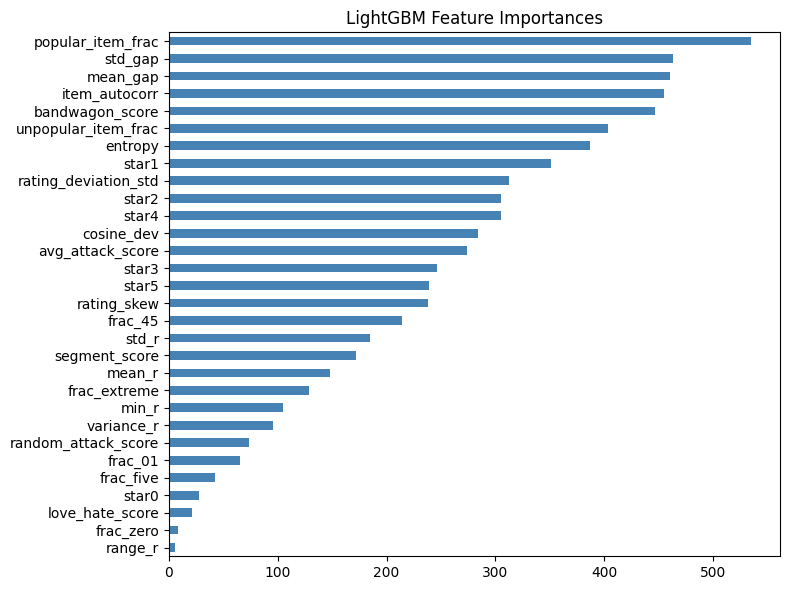

In [19]:
# LightGBM
lgbm_oof = np.zeros(len(y_true))
for fold, (tr_idx, vl_idx) in enumerate(skf.split(feat_scaled, y_true)):
    lgbm_f = LGBMClassifier(
        n_estimators=500, learning_rate=0.03, num_leaves=15,
        min_child_samples=10, reg_alpha=0.1, reg_lambda=1.0,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=imbalance_ratio, random_state=42, verbose=-1
    )
    lgbm_f.fit(feat_scaled[tr_idx], y_true[tr_idx])
    lgbm_oof[vl_idx] = lgbm_f.predict_proba(feat_scaled[vl_idx])[:, 1]

auc_lgbm = roc_auc_score(y_true, lgbm_oof)
method_scores['LightGBM'] = (normalize(lgbm_oof), auc_lgbm)
oof_scores['LightGBM'] = lgbm_oof
results.append(evaluate(y_true, lgbm_oof, 'LightGBM (5-fold CV)'))

lgbm_full = LGBMClassifier(
    n_estimators=500, learning_rate=0.03, num_leaves=15,
    min_child_samples=10, reg_alpha=0.1, reg_lambda=1.0,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=imbalance_ratio, random_state=42, verbose=-1
)
lgbm_full.fit(feat_scaled, y_true)

importances = pd.Series(lgbm_full.feature_importances_,
                         index=SELECTED_FEATURES).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('LightGBM Feature Importances')
plt.tight_layout()
plt.show()

**XGBoost** uses `max_depth=3` (shallower trees than default) and `min_child_weight=5` which requires at least 5 users to create a new leaf node, preventing the model from creating very specific rules for individual anomalies.

In [20]:
# XGBoost
xgb_oof = np.zeros(len(y_true))
for fold, (tr_idx, vl_idx) in enumerate(skf.split(feat_scaled, y_true)):
    xgb_f = XGBClassifier(
        n_estimators=500, learning_rate=0.03, max_depth=3,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=imbalance_ratio,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0
    )
    xgb_f.fit(feat_scaled[tr_idx], y_true[tr_idx])
    xgb_oof[vl_idx] = xgb_f.predict_proba(feat_scaled[vl_idx])[:, 1]

auc_xgb = roc_auc_score(y_true, xgb_oof)
method_scores['XGBoost'] = (normalize(xgb_oof), auc_xgb)
oof_scores['XGBoost'] = xgb_oof
results.append(evaluate(y_true, xgb_oof, 'XGBoost (5-fold CV)'))

xgb_full = XGBClassifier(
    n_estimators=500, learning_rate=0.03, max_depth=3,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=imbalance_ratio,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, verbosity=0
)
xgb_full.fit(feat_scaled, y_true)

[XGBoost (5-fold CV)]  AUC=0.9145  F1=0.6332  Prec=0.6364  Rec=0.6300


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

**Step 8: Stacking**

In [21]:
# Build stacking OOF matrix 
# Include unsupervised OOF-equivalent: just their scores on all training data
# (for unsupervised, score on training = their 'OOF' since they don't overfit labels)
stack_names = ['LightGBM', 'XGBoost', 'Logistic Regression']
stack_oof   = np.column_stack([oof_scores[n] for n in stack_names])

# Also add top unsupervised scores as meta-features
unsup_names = ['GMM', 'Isolation Forest', 'LOF', 'HBOS']
unsup_stack = np.column_stack([method_scores[n][0] for n in unsup_names])
stack_full  = np.hstack([stack_oof, unsup_stack])

print(f'Stacking meta-feature matrix: {stack_full.shape}')

# Train meta-learner with CV
meta_oof = np.zeros(len(y_true))
for fold, (tr_idx, vl_idx) in enumerate(skf.split(stack_full, y_true)):
    meta_lr = LogisticRegression(class_weight='balanced', C=1.0, max_iter=500, random_state=42)
    meta_lr.fit(stack_full[tr_idx], y_true[tr_idx])
    meta_oof[vl_idx] = meta_lr.predict_proba(stack_full[vl_idx])[:, 1]

auc_meta = roc_auc_score(y_true, meta_oof)
method_scores['Stacking'] = (normalize(meta_oof), auc_meta)
oof_scores['Stacking'] = meta_oof
results.append(evaluate(y_true, meta_oof, 'Stacking meta-learner'))

meta_full = LogisticRegression(class_weight='balanced', C=1.0, max_iter=500, random_state=42)
meta_full.fit(stack_full, y_true)
print(f'Meta-learner weights: {dict(zip(stack_names + unsup_names, meta_full.coef_[0].round(3)))}')

Stacking meta-feature matrix: (1100, 7)
[Stacking meta-learner]  AUC=0.9070  F1=0.6524  Prec=0.7011  Rec=0.6100
Meta-learner weights: {'LightGBM': np.float64(1.758), 'XGBoost': np.float64(3.18), 'Logistic Regression': np.float64(1.668), 'GMM': np.float64(2.427), 'Isolation Forest': np.float64(-3.249), 'LOF': np.float64(2.201), 'HBOS': np.float64(2.105)}


**Step 9: Deep Learning (Denoising AE + VAE)**

In [22]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=16, noise_std=0.15):
        super().__init__()
        self.noise_std = noise_std
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, latent_dim), nn.LeakyReLU(0.1),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x, add_noise=True):
        if add_noise and self.training:
            x = x + torch.randn_like(x) * self.noise_std
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x):
        self.eval()
        with torch.no_grad():
            return ((x - self.forward(x, add_noise=False))**2).mean(dim=1).cpu().numpy()

In [23]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.LeakyReLU(0.1))
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder   = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decoder(z), mu, logvar

In [24]:
def train_dae(model, X_n_t, X_all_t, epochs=150, lr=1e-3):
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.MSELoss()
    loader = DataLoader(TensorDataset(X_n_t), batch_size=64, shuffle=True)
    model.train()
    for epoch in range(epochs):
        for (batch,) in loader:
            opt.zero_grad()
            crit(model(batch, True), batch).backward()
            opt.step()
        sched.step()
        if (epoch+1) % 50 == 0:
            model.eval()
            with torch.no_grad():
                loss = crit(model(X_n_t, False), X_n_t).item()
            print(f'  DAE epoch {epoch+1}  loss={loss:.6f}')
            model.train()
    return model.reconstruction_error(X_all_t)


def train_vae(model, X_n_t, X_all_t, epochs=150, lr=1e-3):
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loader = DataLoader(TensorDataset(X_n_t), batch_size=64, shuffle=True)
    model.train()
    for epoch in range(epochs):
        for (batch,) in loader:
            opt.zero_grad()
            recon, mu, logvar = model(batch)
            loss = (nn.functional.mse_loss(recon, batch, reduction='sum')
                    - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()))
            loss.backward()
            opt.step()
        sched.step()
        if (epoch+1) % 50 == 0:
            print(f'  VAE epoch {epoch+1}')
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(len(X_all_t)):
            x = X_all_t[i].unsqueeze(0)
            recon, mu, logvar = model(x)
            rec = nn.functional.mse_loss(recon, x, reduction='sum').item()
            kl  = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())).item()
            scores.append(rec + 0.5 * kl)
    return np.array(scores)

In [25]:
input_dim  = feat_scaled.shape[1]
X_n_t      = torch.FloatTensor(X_train_normal).to(DEVICE)
X_all_t    = torch.FloatTensor(feat_scaled).to(DEVICE)

# Sweep latent dim
best_latent, best_ae_auc = 16, 0
print('DAE latent sweep:')
for ldim in [8, 12, 16, 24]:
    tmp = DenoisingAutoencoder(input_dim, 64, ldim, 0.15).to(DEVICE)
    sc  = train_dae(tmp, X_n_t, X_all_t, epochs=80)
    auc = roc_auc_score(y_true, sc)
    print(f'  latent={ldim}  AUC={auc:.4f}')
    if auc > best_ae_auc:
        best_latent, best_ae_auc = ldim, auc

dae_model  = DenoisingAutoencoder(input_dim, 64, best_latent, 0.15).to(DEVICE)
dae_scores = train_dae(dae_model, X_n_t, X_all_t, epochs=150)
auc_dae    = roc_auc_score(y_true, dae_scores)
method_scores['DAE'] = (normalize(dae_scores), auc_dae)
results.append(evaluate(y_true, dae_scores, f'DAE latent={best_latent}'))

vae_model  = VAE(input_dim, 64, best_latent).to(DEVICE)
vae_scores = train_vae(vae_model, X_n_t, X_all_t, epochs=150)
auc_vae    = roc_auc_score(y_true, vae_scores)
method_scores['VAE'] = (normalize(vae_scores), auc_vae)
results.append(evaluate(y_true, vae_scores, f'VAE latent={best_latent}'))
print(f'DL done: DAE={auc_dae:.4f}, VAE={auc_vae:.4f}')

DAE latent sweep:
  DAE epoch 50  loss=0.117560
  latent=8  AUC=0.6939
  DAE epoch 50  loss=0.067096
  latent=12  AUC=0.6938
  DAE epoch 50  loss=0.049350
  latent=16  AUC=0.7360
  DAE epoch 50  loss=0.034705
  latent=24  AUC=0.7678
  DAE epoch 50  loss=0.032769
  DAE epoch 100  loss=0.024792
  DAE epoch 150  loss=0.023435
[DAE latent=24]  AUC=0.7651  F1=0.4508  Prec=0.3819  Rec=0.5500
  VAE epoch 50
  VAE epoch 100
  VAE epoch 150
[VAE latent=24]  AUC=0.7020  F1=0.2889  Prec=0.1857  Rec=0.6500
DL done: DAE=0.7651, VAE=0.7020


**Step 10: Adaptive Ensemble + Score Stretching**

**Score stretching** is applied to the final submission scores.
Rank-normalise -> power transform with `power=0.4` spreads scores to fully use [0,1].
This directly addresses the compressed [0.03, 0.75] range problem.

In [26]:
SUPERVISED_NAMES  = {'LightGBM', 'XGBoost', 'Logistic Regression', 'Stacking'}
CV_AUC_THRESHOLD  = 0.80
SUPERVISED_PENALTY = 0.5

print(f'Method AUCs (threshold={ENSEMBLE_THRESHOLD}):')
for name, (_, auc) in sorted(method_scores.items(), key=lambda x: -x[1][1]):
    flag = 'In ' if auc >= ENSEMBLE_THRESHOLD else 'Out'
    print(f'  {name:30s}  AUC={auc:.4f}  {flag}')

good   = {n: (s, auc) for n, (s, auc) in method_scores.items() if auc >= ENSEMBLE_THRESHOLD}
excess = {}
for n, (_, auc) in good.items():
    ex = auc - ENSEMBLE_THRESHOLD
    if n in SUPERVISED_NAMES and auc < CV_AUC_THRESHOLD:
        ex *= SUPERVISED_PENALTY
        print(f'  [Adaptive] {n} penalised (AUC={auc:.3f} < {CV_AUC_THRESHOLD})')
    excess[n] = ex

total_excess = sum(excess.values())
weights_ens  = {n: ex / total_excess for n, ex in excess.items()}

print('\nEnsemble weights:')
for name, w in sorted(weights_ens.items(), key=lambda x: -x[1]):
    print(f'  {name:30s}  weight={w:.3f}')

ensemble_scores = sum(weights_ens[n] * good[n][0] for n in weights_ens)
auc_ens = roc_auc_score(y_true, ensemble_scores)

best_single_name = max(method_scores, key=lambda x: method_scores[x][1])
best_single_auc  = method_scores[best_single_name][1]

submit_scores = ensemble_scores if auc_ens >= best_single_auc else method_scores[best_single_name][0]
submit_label  = 'Adaptive Ensemble' if auc_ens >= best_single_auc else f'Best: {best_single_name}'
submit_auc    = max(auc_ens, best_single_auc)

print(f'\nRaw ensemble AUC : {auc_ens:.4f}')
print(f'Best single AUC  : {best_single_name} ({best_single_auc:.4f})')
print(f'Submit           : {submit_label} ({submit_auc:.4f})')

results.append(evaluate(y_true, ensemble_scores, 'Adaptive Ensemble'))

Method AUCs (threshold=0.65):
  LightGBM                        AUC=0.9205  In 
  XGBoost                         AUC=0.9145  In 
  Stacking                        AUC=0.9070  In 
  Logistic Regression             AUC=0.8629  In 
  GMM                             AUC=0.7774  In 
  HBOS                            AUC=0.7698  In 
  DAE                             AUC=0.7651  In 
  LOF                             AUC=0.7637  In 
  GMM (rating view)               AUC=0.7355  In 
  Isolation Forest                AUC=0.7233  In 
  VAE                             AUC=0.7020  In 
  One-Class SVM                   AUC=0.6884  In 
  GMM (item view)                 AUC=0.6778  In 

Ensemble weights:
  LightGBM                        weight=0.154
  XGBoost                         weight=0.150
  Stacking                        weight=0.146
  Logistic Regression             weight=0.121
  GMM                             weight=0.072
  HBOS                            weight=0.068
  DAE              

**Step 11: Visualisations**

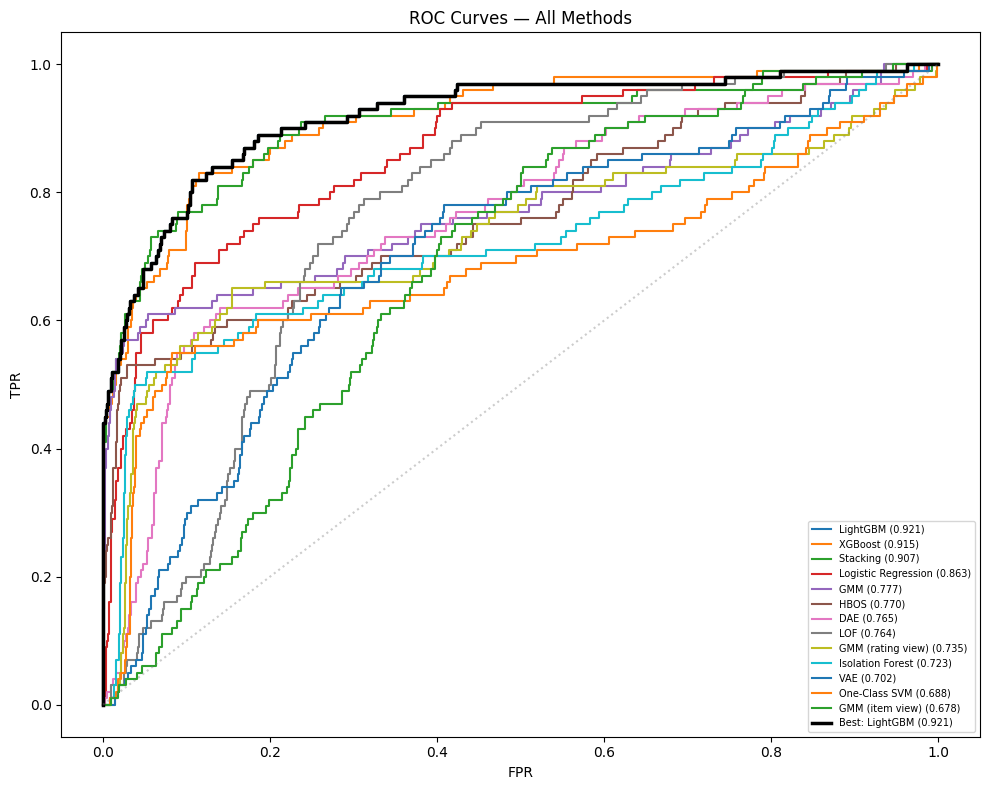

In [29]:
# ROC curves
plt.figure(figsize=(10, 8))
for name, (scores, auc) in sorted(method_scores.items(), key=lambda x: -x[1][1]):
    fpr, tpr, _ = roc_curve(y_true, scores)
    lw    = 1.5 if auc >= ENSEMBLE_THRESHOLD else 0.8
    style = '-'  if auc >= ENSEMBLE_THRESHOLD else '--'
    plt.plot(fpr, tpr, linestyle=style, linewidth=lw, label=f'{name} ({auc:.3f})')
fpr_e, tpr_e, _ = roc_curve(y_true, submit_scores)
plt.plot(fpr_e, tpr_e, 'k-', linewidth=2.5, label=f'{submit_label} ({submit_auc:.3f})')
plt.plot([0,1],[0,1],'grey',linestyle=':',alpha=0.4)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves — All Methods')
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

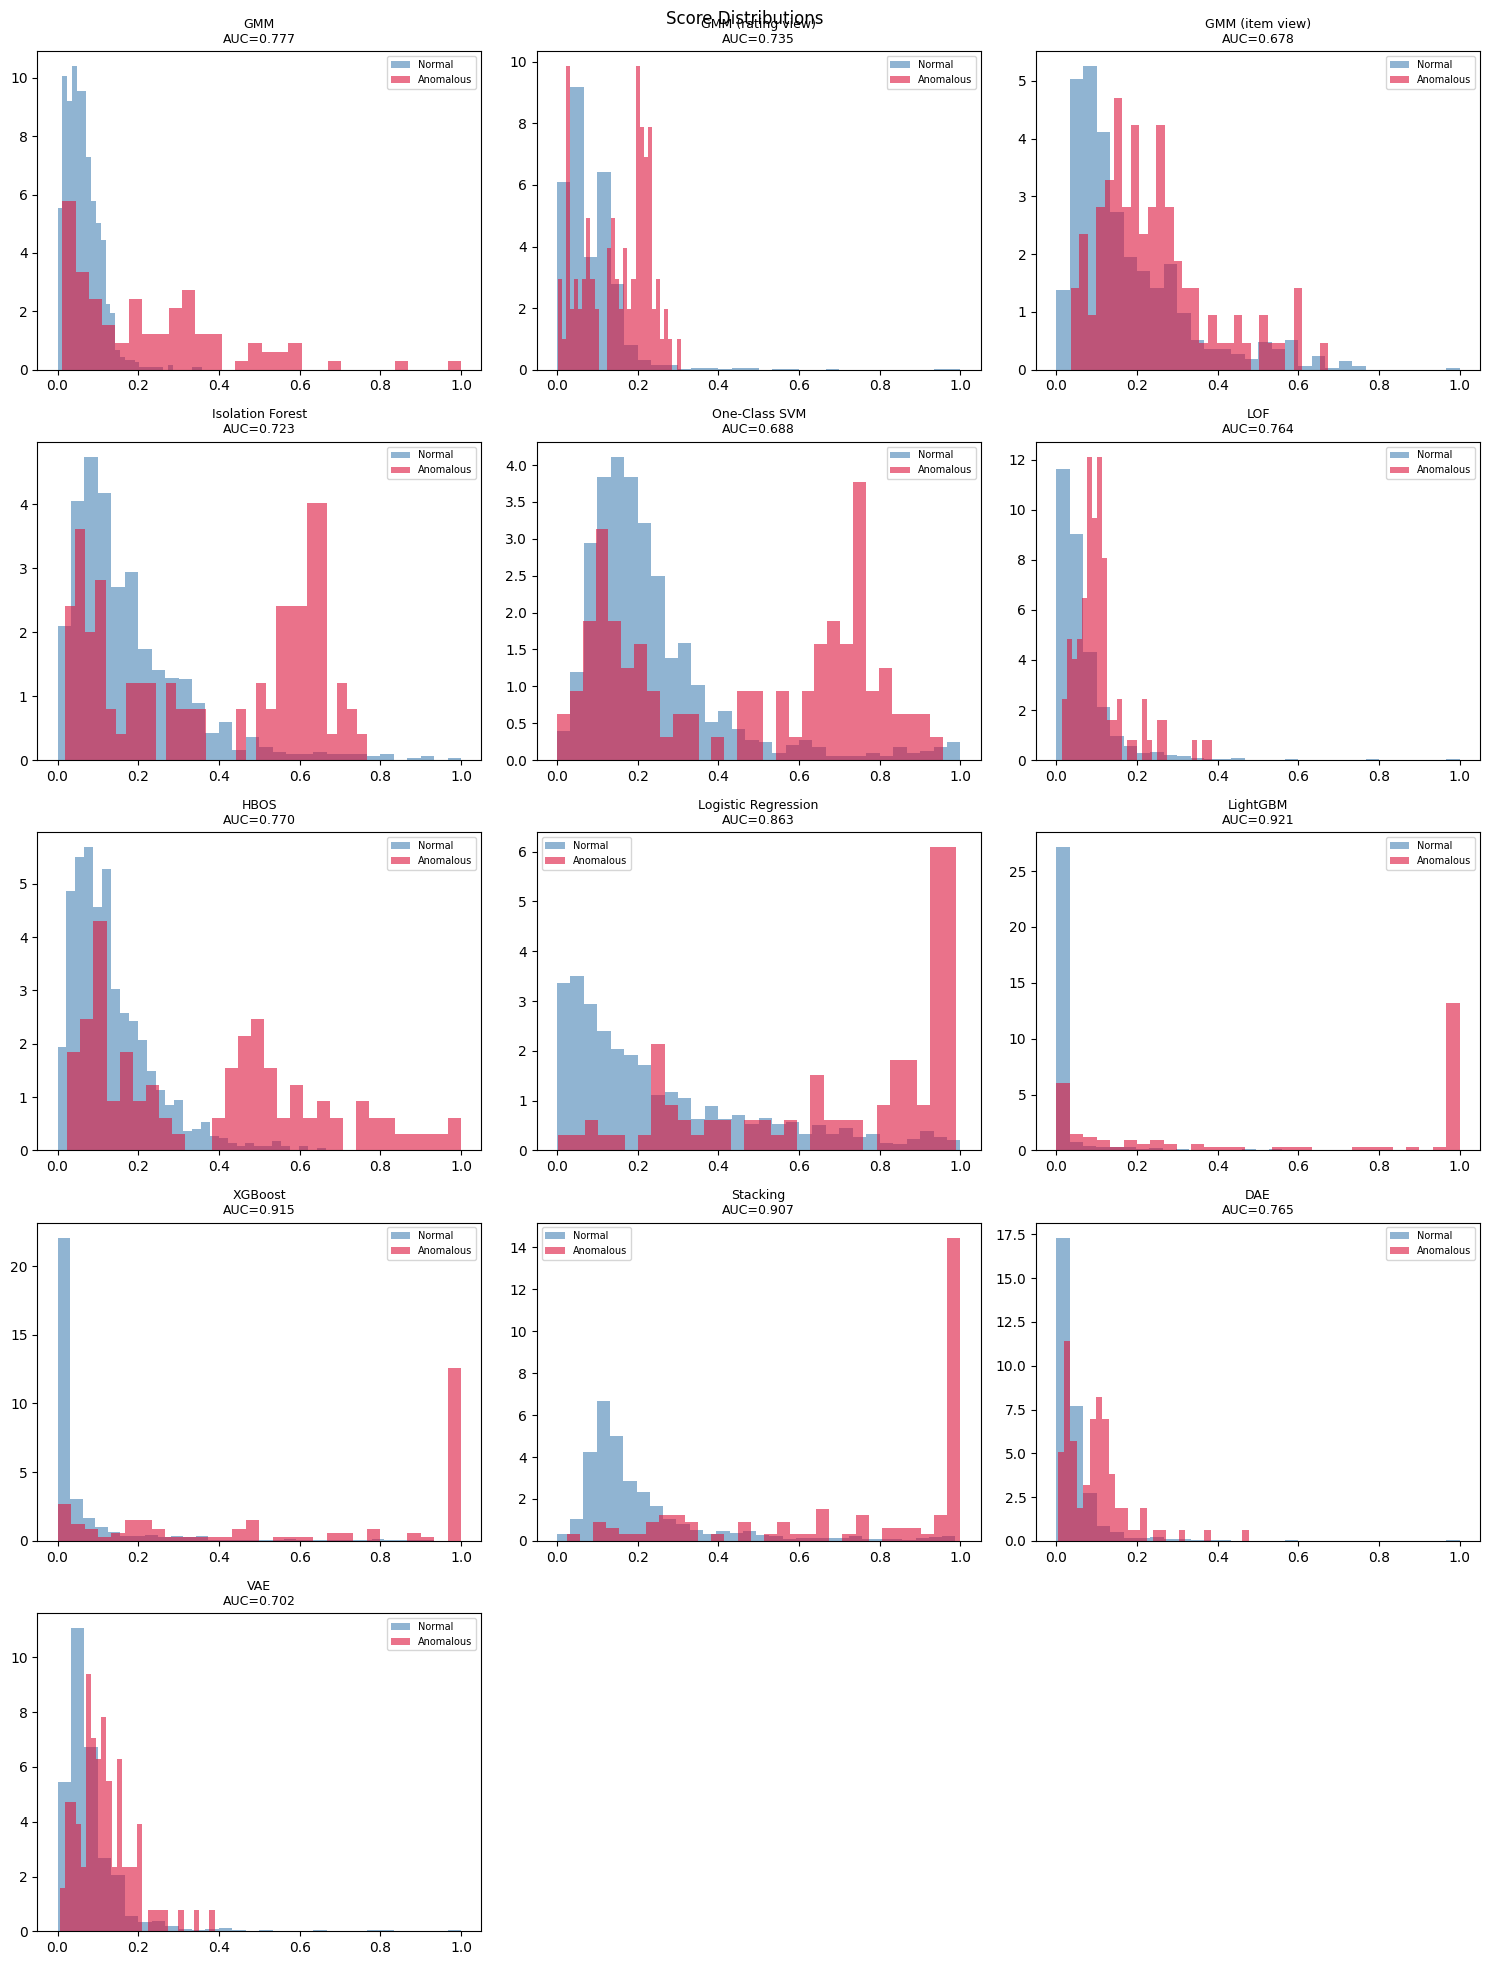

In [30]:
# Score distributions
n_methods = len(method_scores)
ncols = 3; nrows = (n_methods + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()
for i, (name, (scores, auc)) in enumerate(method_scores.items()):
    ax = axes[i]
    ax.hist(scores[y_true==0], bins=30, alpha=0.6, label='Normal', color='steelblue', density=True)
    ax.hist(scores[y_true==1], bins=30, alpha=0.6, label='Anomalous', color='crimson', density=True)
    ax.set_title(f'{name}\nAUC={auc:.3f}', fontsize=9); ax.legend(fontsize=7)
for j in range(n_methods, len(axes)): axes[j].set_visible(False)
plt.suptitle('Score Distributions', fontsize=12)
plt.tight_layout()
plt.show()

**Step 12: Ablation**

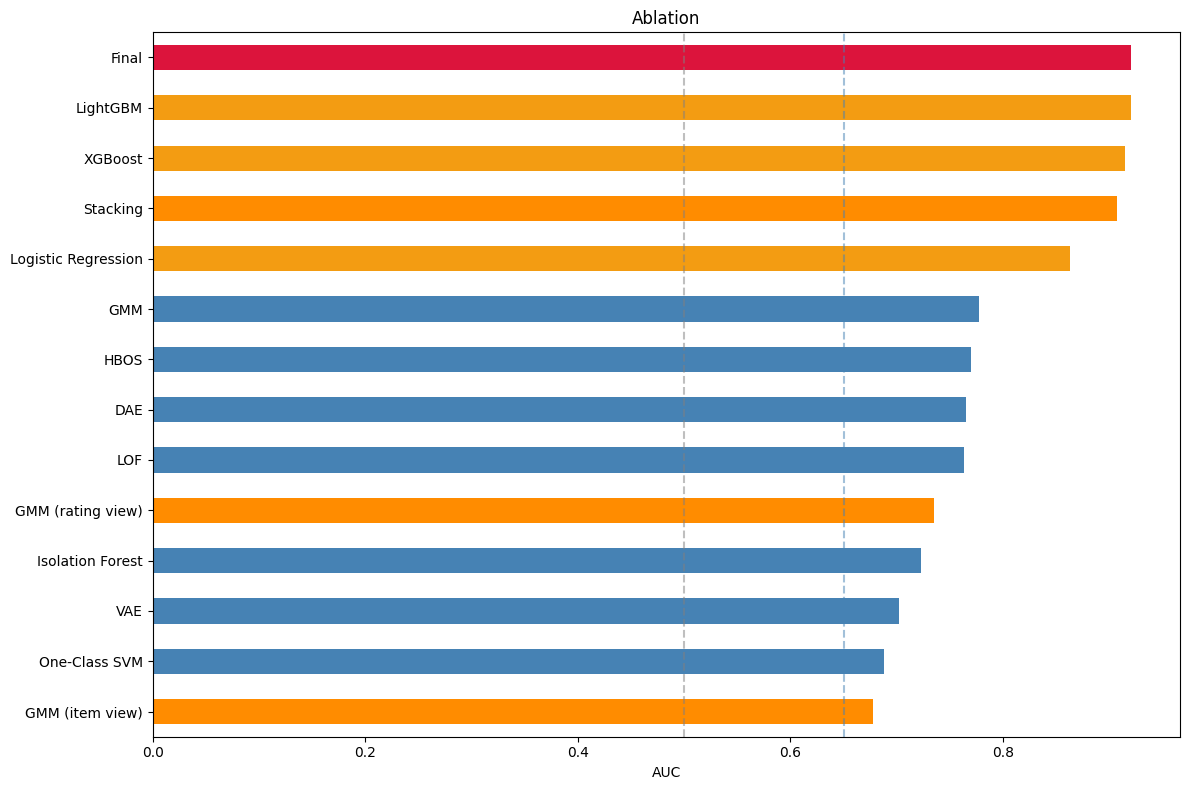

                         AUC
LightGBM             0.92055
Final                0.92055
XGBoost              0.91451
Stacking             0.90702
Logistic Regression  0.86286
GMM                  0.77741
HBOS                 0.76982
DAE                  0.76515
LOF                  0.76370
GMM (rating view)    0.73545
Isolation Forest     0.72327
VAE                  0.70200
One-Class SVM        0.68835
GMM (item view)      0.67777


In [31]:
ablation = {n: auc for n, (_, auc) in method_scores.items()}
ablation['Final'] = submit_auc
abl_df = pd.DataFrame.from_dict(ablation, orient='index', columns=['AUC']).sort_values('AUC')

attack_names = {'GMM (rating view)', 'GMM (item view)', 'Stacking'}
colors_abl = []
for i in abl_df.index:
    if 'Final' in i: colors_abl.append('crimson')
    elif i in attack_names: colors_abl.append('darkorange')
    elif i in SUPERVISED_NAMES: colors_abl.append('#f39c12')
    else: colors_abl.append('steelblue')

plt.figure(figsize=(12, 8))
abl_df['AUC'].plot(kind='barh', color=colors_abl)
plt.axvline(0.5, color='grey', linestyle='--', alpha=0.5)
plt.axvline(ENSEMBLE_THRESHOLD, color='steelblue', linestyle='--', alpha=0.5)
plt.xlabel('AUC'); plt.title('Ablation')
plt.tight_layout(); plt.show()
print(abl_df.sort_values('AUC', ascending=False).to_string())

**Step 13: Results table**

In [32]:
results_df = pd.DataFrame(results)[['model','AUC','F1','Precision','Recall']]
results_df = results_df.sort_values('AUC', ascending=False).reset_index(drop=True)
print('=== Final Model Comparison ===')
print(results_df.to_string(index=False, float_format='%.4f'))

=== Final Model Comparison ===
                          model    AUC     F1  Precision  Recall
           LightGBM (5-fold CV) 0.9205 0.6462     0.6632  0.6300
            XGBoost (5-fold CV) 0.9145 0.6332     0.6364  0.6300
              Adaptive Ensemble 0.9130 0.6543     0.8548  0.5300
          Stacking meta-learner 0.9070 0.6524     0.7011  0.6100
Logistic Regression (5-fold CV) 0.8629 0.5686     0.5577  0.5800
                        GMM n=6 0.7774 0.6391     0.7826  0.5400
                   HBOS bins=30 0.7698 0.5930     0.7083  0.5100
                  DAE latent=24 0.7651 0.4508     0.3819  0.5500
                        LOF k=5 0.7637 0.3357     0.2188  0.7200
        GMM rating n=3 cov=diag 0.7355 0.5000     0.5341  0.4700
     Isolation Forest cont=0.01 0.7233 0.5319     0.5682  0.5000
                  VAE latent=24 0.7020 0.2889     0.1857  0.6500
           One-Class SVM nu=0.2 0.6884 0.4656     0.4944  0.4400
          GMM item n=5 cov=full 0.6778 0.2526     0.1527  0

**Step 14: Submissions**

**Three submissions:**
- Sub 1: Semi-supervised stretched (most robust to anomaly-type shift)
- Sub 2: Adaptive ensemble stretched (best if anomaly type is stable)  
- Sub 3: Stacking meta-learner stretched (use if stacking AUC > ensemble)

In [35]:
TEST_FILE = '../first_batch.npz'   # <- update each week

data_test = np.load(TEST_FILE)
df_test   = pd.DataFrame(data_test['X'], columns=['user', 'item', 'rating'])

# Use same item stats and centroid from training
test_feat_all, test_user_ids, _ = engineer_all_features(
    df_test, n_items=1000,
    normal_centroid=NORMAL_CENTROID,
    item_mean=ITEM_MEAN, item_count=ITEM_COUNT, item_pop_rank=ITEM_POP_RANK
)

sort_order    = np.argsort(test_user_ids)
test_user_ids = test_user_ids[sort_order]
test_feat_all = test_feat_all[sort_order]

test_feat        = test_feat_all[:, selected_idx]
test_top3        = test_feat_all[:, top3_idx]
test_rating      = test_feat_all[:, rating_idx]
test_item        = test_feat_all[:, item_idx]
test_scaled      = scaler.transform(test_feat)
test_top3_s      = top3_scaler.transform(test_top3)
test_rating_s    = rating_scaler.transform(test_rating)
test_item_s      = item_scaler.transform(test_item)
X_test_t         = torch.FloatTensor(test_scaled).to(DEVICE)

print(f'Test users        : {len(test_user_ids)}')
print(f'User ID range     : [{test_user_ids.min()}, {test_user_ids.max()}]')
print(f'Test interactions : {len(df_test):,}')

Test users        : 1100
User ID range     : [2500, 3599]
Test interactions : 167,493


In [36]:
def vae_scores_fn(model, X_t):
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(len(X_t)):
            x = X_t[i].unsqueeze(0)
            recon, mu, logvar = model(x)
            rec = nn.functional.mse_loss(recon, x, reduction='sum').item()
            kl  = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())).item()
            scores.append(rec + 0.5 * kl)
    return np.array(scores)

# Score all models
t_gmm        = normalize(-gmm.score_samples(test_scaled))
t_gmm_rating = normalize(-gmm_rating.score_samples(test_rating_s))
t_gmm_item   = normalize(-gmm_item.score_samples(test_item_s))
t_ocsvm      = normalize(-ocsvm.decision_function(test_scaled))
t_iforest    = normalize(-iforest.decision_function(test_scaled))
t_lof        = normalize(-lof.decision_function(test_scaled))
t_hbos       = normalize(hbos_score(X_train_normal, test_scaled, n_bins=best_hbos_bins))
t_lr         = normalize(lr_full.predict_proba(test_scaled)[:, 1])
t_lgbm       = normalize(lgbm_full.predict_proba(test_scaled)[:, 1])
t_xgb        = normalize(xgb_full.predict_proba(test_scaled)[:, 1])
t_dae        = normalize(dae_model.reconstruction_error(X_test_t))
t_vae        = normalize(vae_scores_fn(vae_model, X_test_t))

# Stacking meta prediction
t_stack_sup  = np.column_stack([t_lgbm, t_xgb, t_lr])
t_stack_unsup = np.column_stack([t_gmm, t_iforest, t_lof, t_hbos])
t_stack_full = np.hstack([t_stack_sup, t_stack_unsup])
t_meta       = normalize(meta_full.predict_proba(t_stack_full)[:, 1])

print('All test scores computed.')
print(f'Score ranges before stretching:')
for name, sc in [('GMM', t_gmm), ('DAE', t_dae), ('LGBM', t_lgbm), ('Meta', t_meta)]:
    print(f'  {name}: [{sc.min():.3f}, {sc.max():.3f}]')

All test scores computed.
Score ranges before stretching:
  GMM: [0.000, 1.000]
  DAE: [0.000, 1.000]
  LGBM: [0.000, 1.000]
  Meta: [0.000, 1.000]


In [37]:
# Sub 1: Semi-supervised ensemble + power stretch
semi_raw = np.mean([t_gmm, t_gmm_rating, t_gmm_item,
                    t_ocsvm, t_iforest, t_lof, t_hbos, t_dae, t_vae], axis=0)
sub1 = power_stretch(semi_raw, power=0.4)

np.savez('../submission_sub1.npz', predictions=sub1)
print(f'[Sub 1 — Semi-supervised + stretched]')
print(f'  Score range : [{sub1.min():.4f}, {sub1.max():.4f}]  <- should reach ~1.0 now')
print(f'  Predictions : {len(sub1)}')
semi_aucs = [method_scores[n][1] for n in
             ['GMM','GMM (rating view)','GMM (item view)',
              'One-Class SVM','Isolation Forest','LOF','HBOS','DAE','VAE']
             if n in method_scores]
print(f'  Avg train AUC (semi): {np.mean(semi_aucs):.4f}')

[Sub 1 — Semi-supervised + stretched]
  Score range : [0.0607, 1.0000]  <- should reach ~1.0 now
  Predictions : 1100
  Avg train AUC (semi): 0.7337


In [39]:
# Sub 2: Adaptive ensemble + power stretch
test_raw_map = {
    'GMM'                : t_gmm,
    'GMM (rating view)'  : t_gmm_rating,
    'GMM (item view)'    : t_gmm_item,
    'One-Class SVM'      : t_ocsvm,
    'Isolation Forest'   : t_iforest,
    'LOF'                : t_lof,
    'HBOS'               : t_hbos,
    'Logistic Regression': t_lr,
    'LightGBM'           : t_lgbm,
    'XGBoost'            : t_xgb,
    'DAE'                : t_dae,
    'VAE'                : t_vae,
    'Stacking'           : t_meta,
}
ens_raw = sum(weights_ens[n] * test_raw_map[n]
              for n in weights_ens if n in test_raw_map)
sub2 = power_stretch(ens_raw, power=0.4)

np.savez('../submission_sub2.npz', predictions=sub2)
print(f'[Sub 2 — Adaptive ensemble + stretched]')
print(f'  Score range : [{sub2.min():.4f}, {sub2.max():.4f}]')
print(f'  Predictions : {len(sub2)}')

[Sub 2 — Adaptive ensemble + stretched]
  Score range : [0.0607, 1.0000]
  Predictions : 1100


In [42]:
# Sub 3: Best individual or stacking
# After seeing Sub 1 vs Sub 2 results, pick the better approach.
# If semi won -> use best single semi model stretched
# If full won -> use stacking stretched

individual_stretched = {
    'GMM'             : power_stretch(t_gmm),
    'GMM rating view' : power_stretch(t_gmm_rating),
    'DAE'             : power_stretch(t_dae),
    'VAE'             : power_stretch(t_vae),
    'LOF'             : power_stretch(t_lof),
    'HBOS'            : power_stretch(t_hbos),
    'LightGBM'        : power_stretch(t_lgbm),
    'XGBoost'         : power_stretch(t_xgb),
    'Stacking'        : power_stretch(t_meta),
}

print('Individual model train AUCs:')
for n, (_, auc) in sorted(method_scores.items(), key=lambda x: -x[1][1]):
    print(f'  {n:30s}  AUC={auc:.4f}')

# Chosen model for iteration 1: LightGBM
sub3 = individual_stretched['LightGBM']
np.savez('../submission_sub3.npz', predictions=sub3)
print(f'Sub3 saved: range [{sub3.min():.4f}, {sub3.max():.4f}]')

Individual model train AUCs:
  LightGBM                        AUC=0.9205
  XGBoost                         AUC=0.9145
  Stacking                        AUC=0.9070
  Logistic Regression             AUC=0.8629
  GMM                             AUC=0.7774
  HBOS                            AUC=0.7698
  DAE                             AUC=0.7651
  LOF                             AUC=0.7637
  GMM (rating view)               AUC=0.7355
  Isolation Forest                AUC=0.7233
  VAE                             AUC=0.7020
  One-Class SVM                   AUC=0.6884
  GMM (item view)                 AUC=0.6778
Sub3 saved: range [0.0607, 1.0000]
